In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
os.chdir('/content/drive/MyDrive/NLP/BBC News Classification')
!ls

'BBC News Classification.ipynb'   bbc-text.csv


In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from nltk.corpus import stopwords
import re
from sklearn.metrics import confusion_matrix,classification_report
from transformers import BertTokenizer,TFBertModel
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import RandomOverSampler
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow.keras.layers import Dense,Input
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Lambda
from huggingface_hub import login
from huggingface_hub import Repository
import warnings
warnings.filterwarnings('ignore')

In [4]:
data = pd.read_csv('bbc-text.csv')
data.head()

,category,text
0,tech,tv future in the hands of viewers with home th...
1,business,worldcom boss left books alone former worldc...
2,sport,tigers wary of farrell gamble leicester say ...
3,sport,yeading face newcastle in fa cup premiership s...
4,entertainment,ocean s twelve raids box office ocean s twelve...


In [5]:
print(f'The dataset has {data.shape[0]} Rows and {data.shape[1]} columns')

The dataset has 2225 Rows and 2 columns


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2225 entries, 0 to 2224
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   category  2225 non-null   object
 1   text      2225 non-null   object
dtypes: object(2)
memory usage: 34.9+ KB


In [7]:
data.isna().sum()

,0
category,0
text,0


In [8]:
data.category.value_counts().to_frame()

,count
category,
sport,511
business,510
politics,417
tech,401
entertainment,386


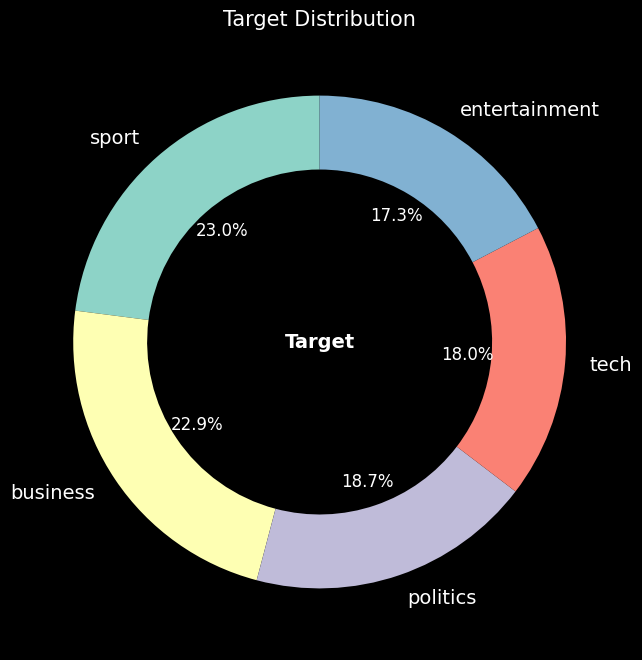

In [9]:
plt.style.use('dark_background')
plt.figure(figsize=(8, 8))
wedges, texts, autotexts = plt.pie(
    data.category.value_counts(), labels=data.category.value_counts().index, autopct='%1.1f%%', startangle=90,
    wedgeprops={'width': 0.3}
)
plt.text(0, 0, 'Target', ha='center', va='center', fontsize=14, fontweight='bold')
plt.title("Target Distribution", fontsize=15)
plt.setp(autotexts, size=12, color="white")
plt.setp(texts, size=14, color="white")
plt.show()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


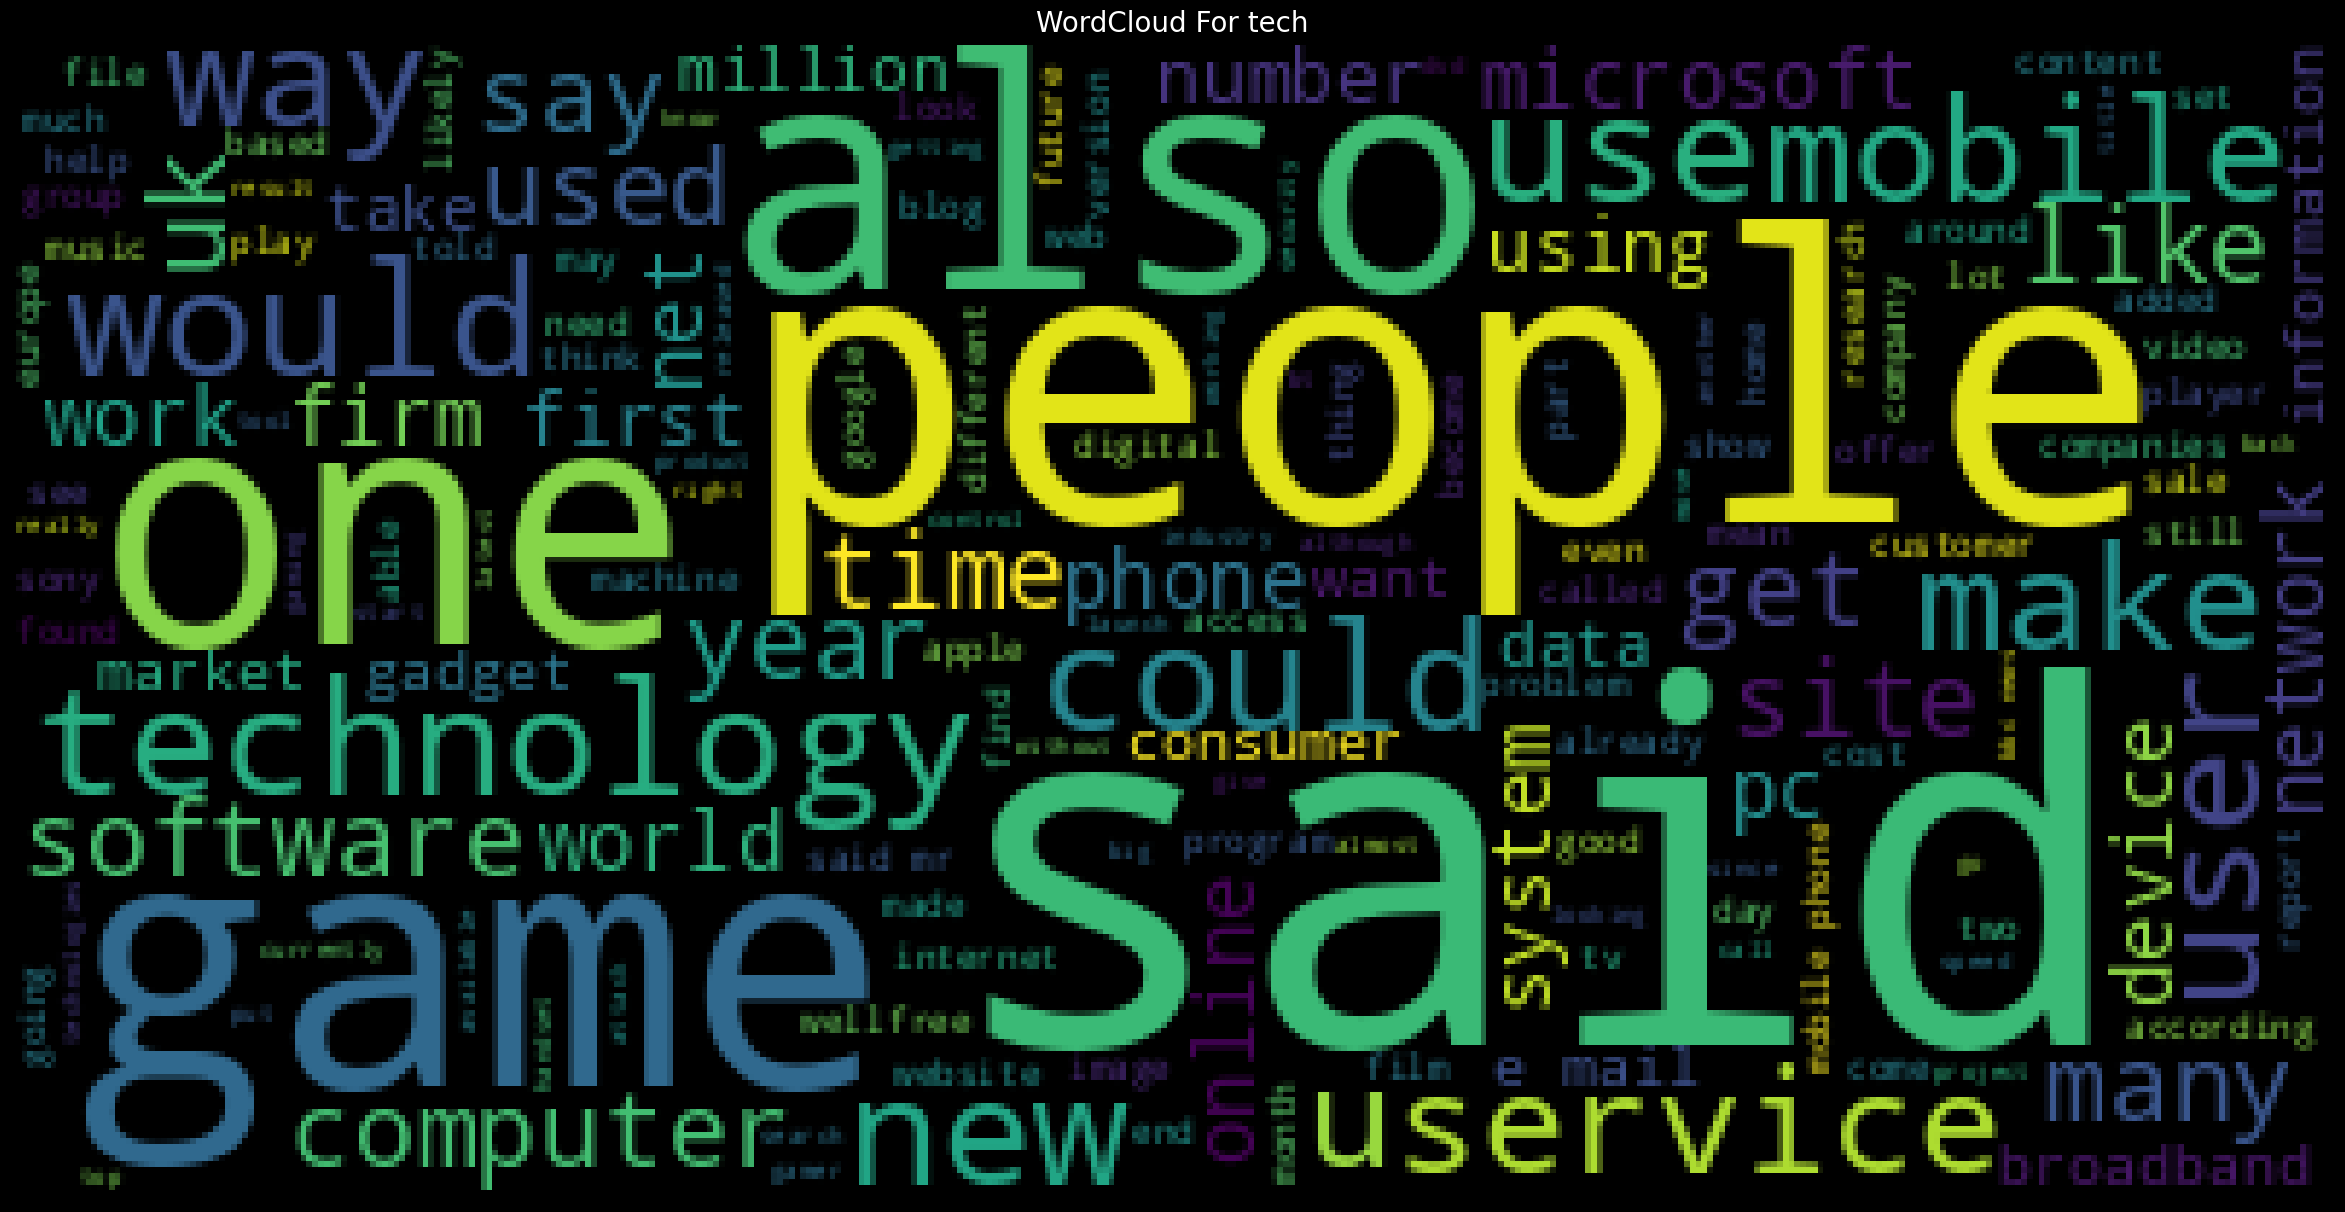

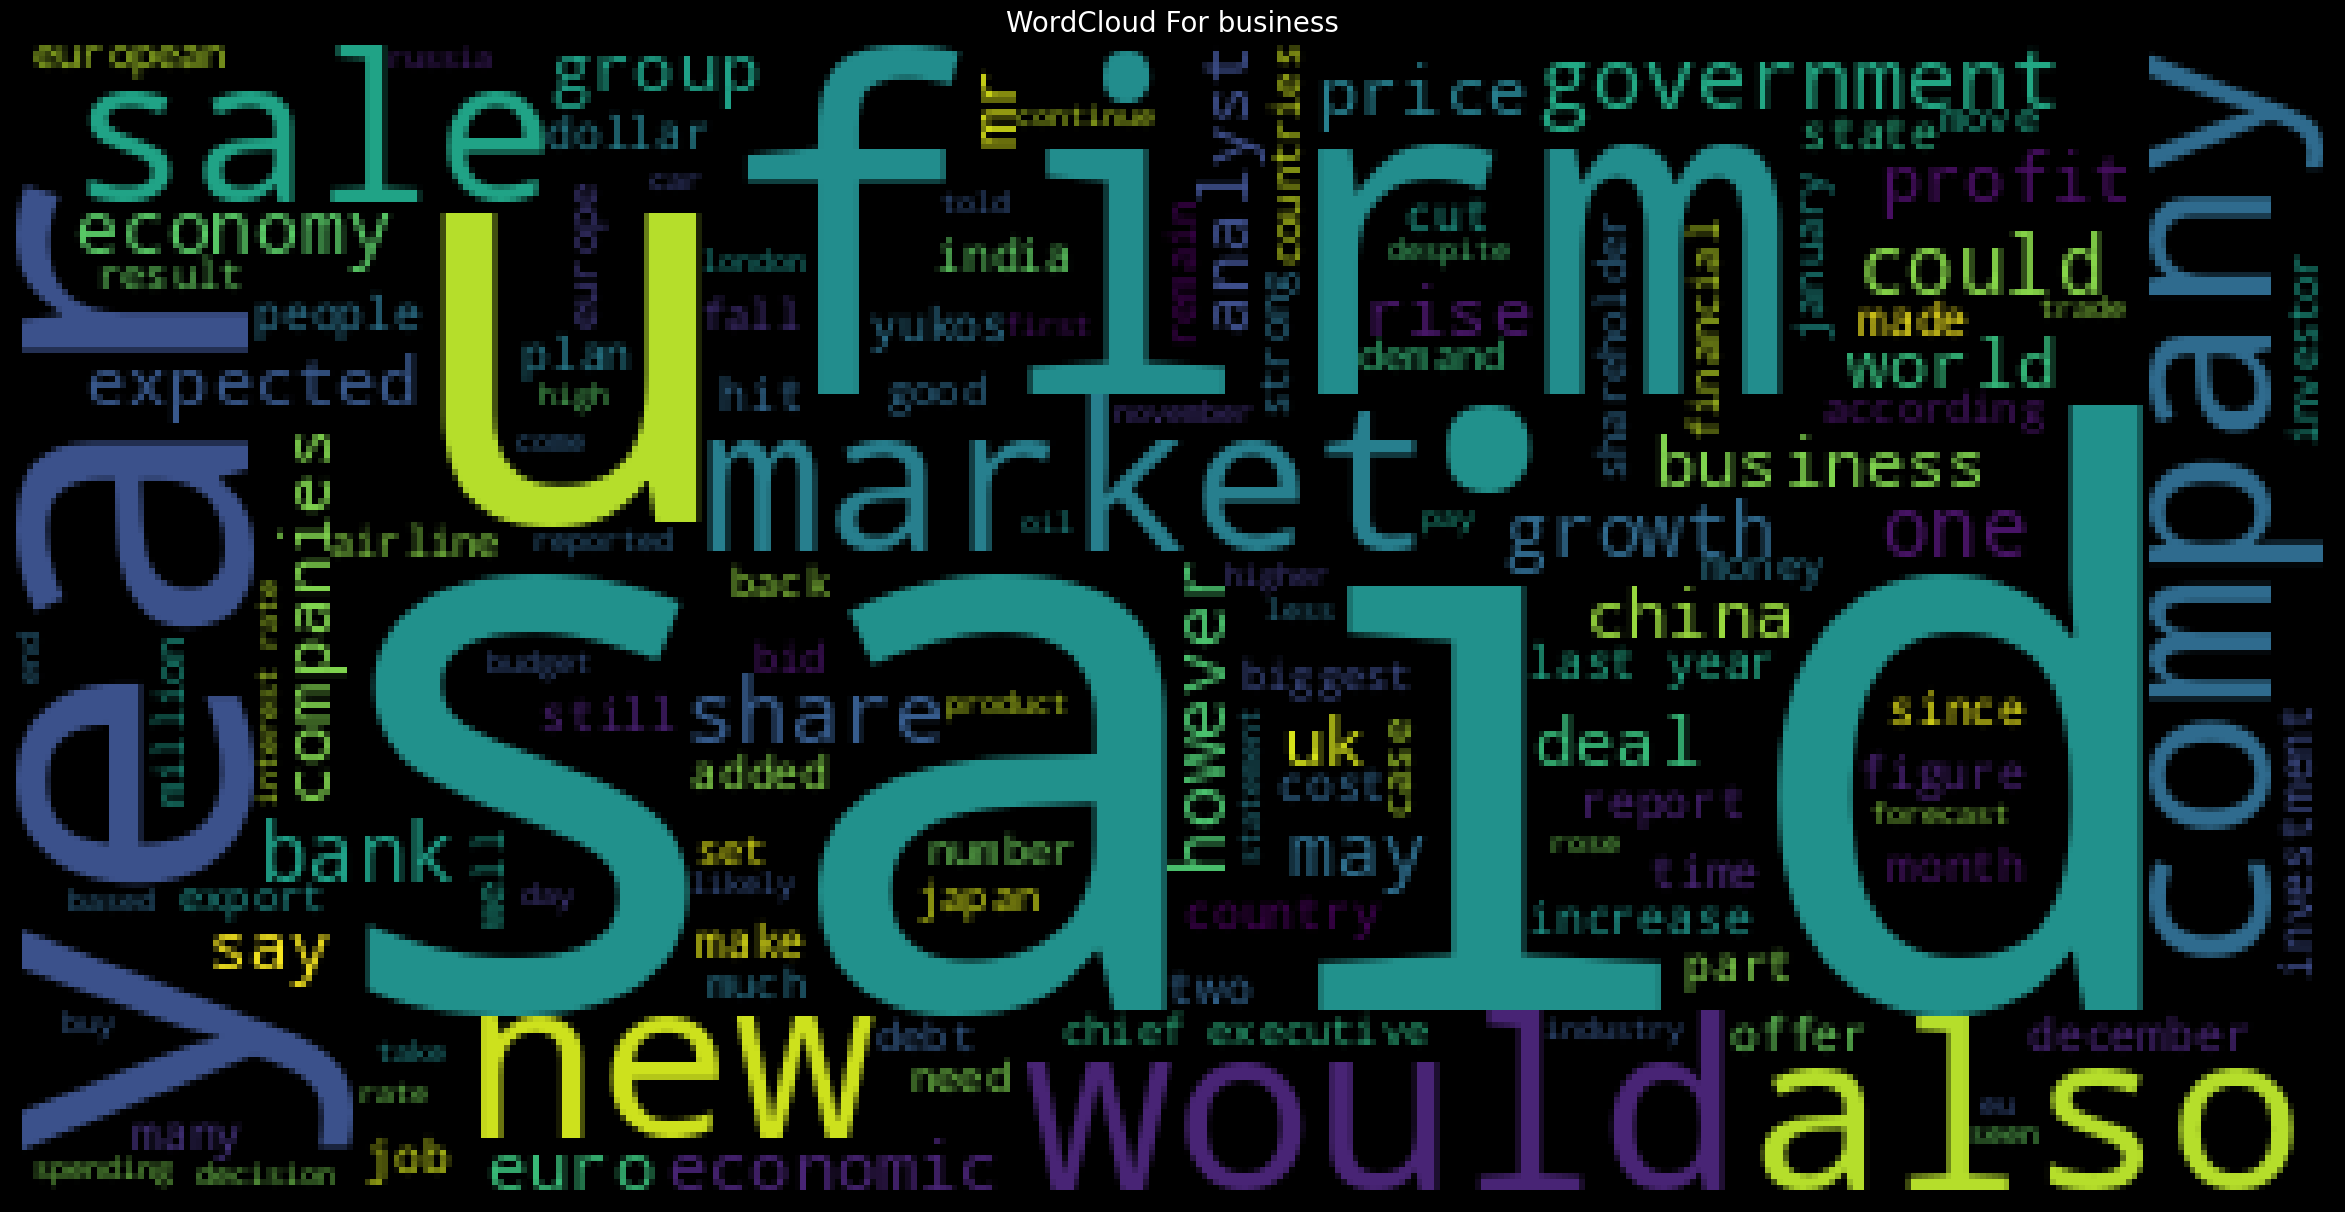

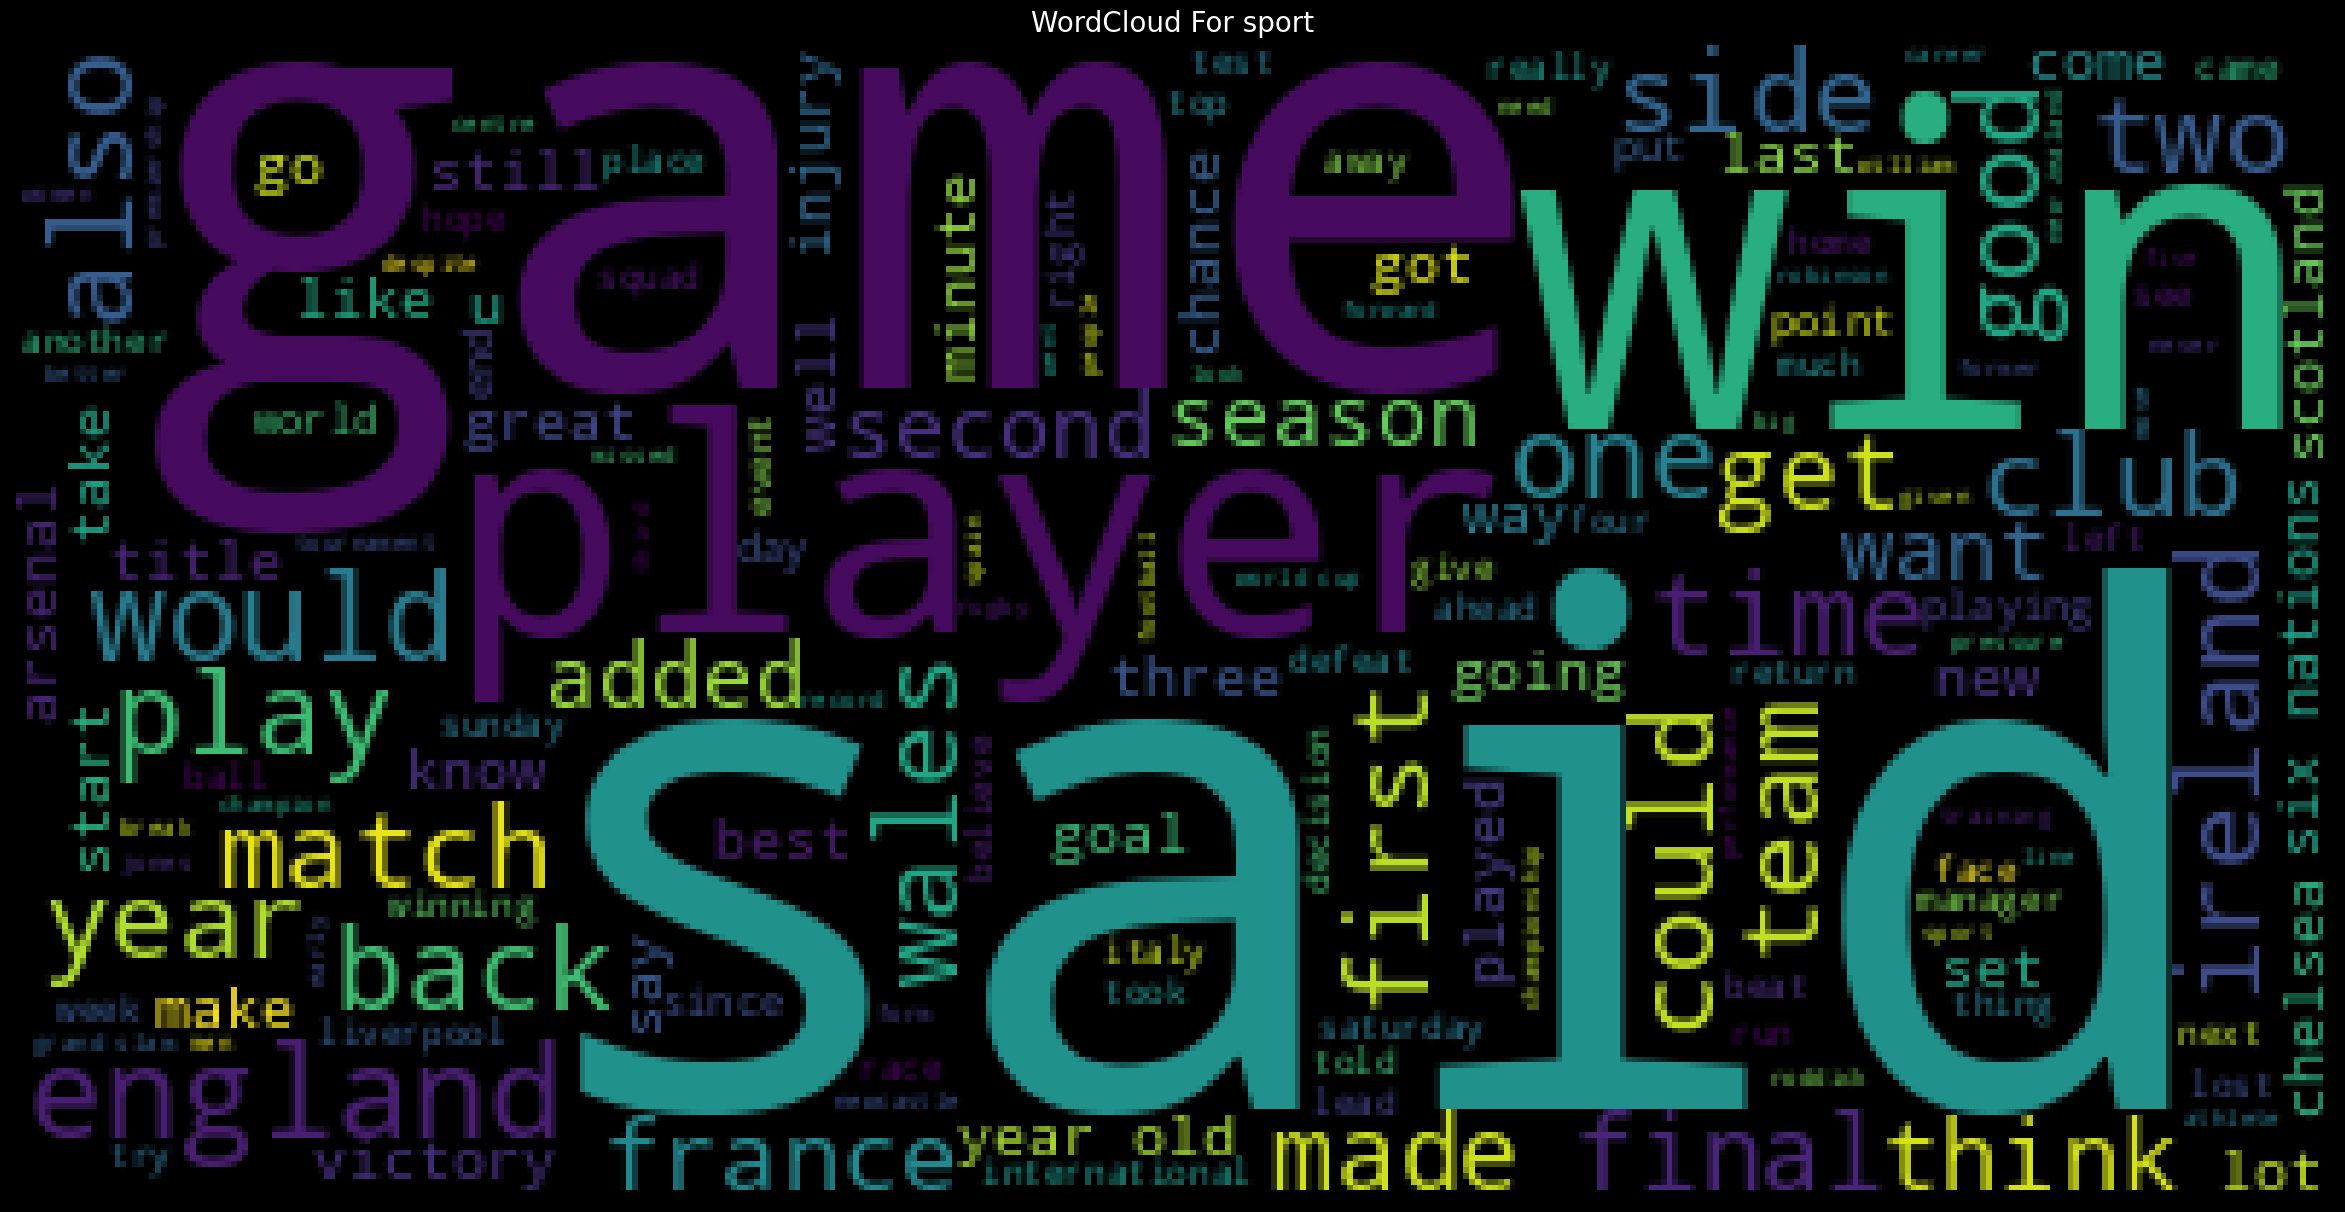

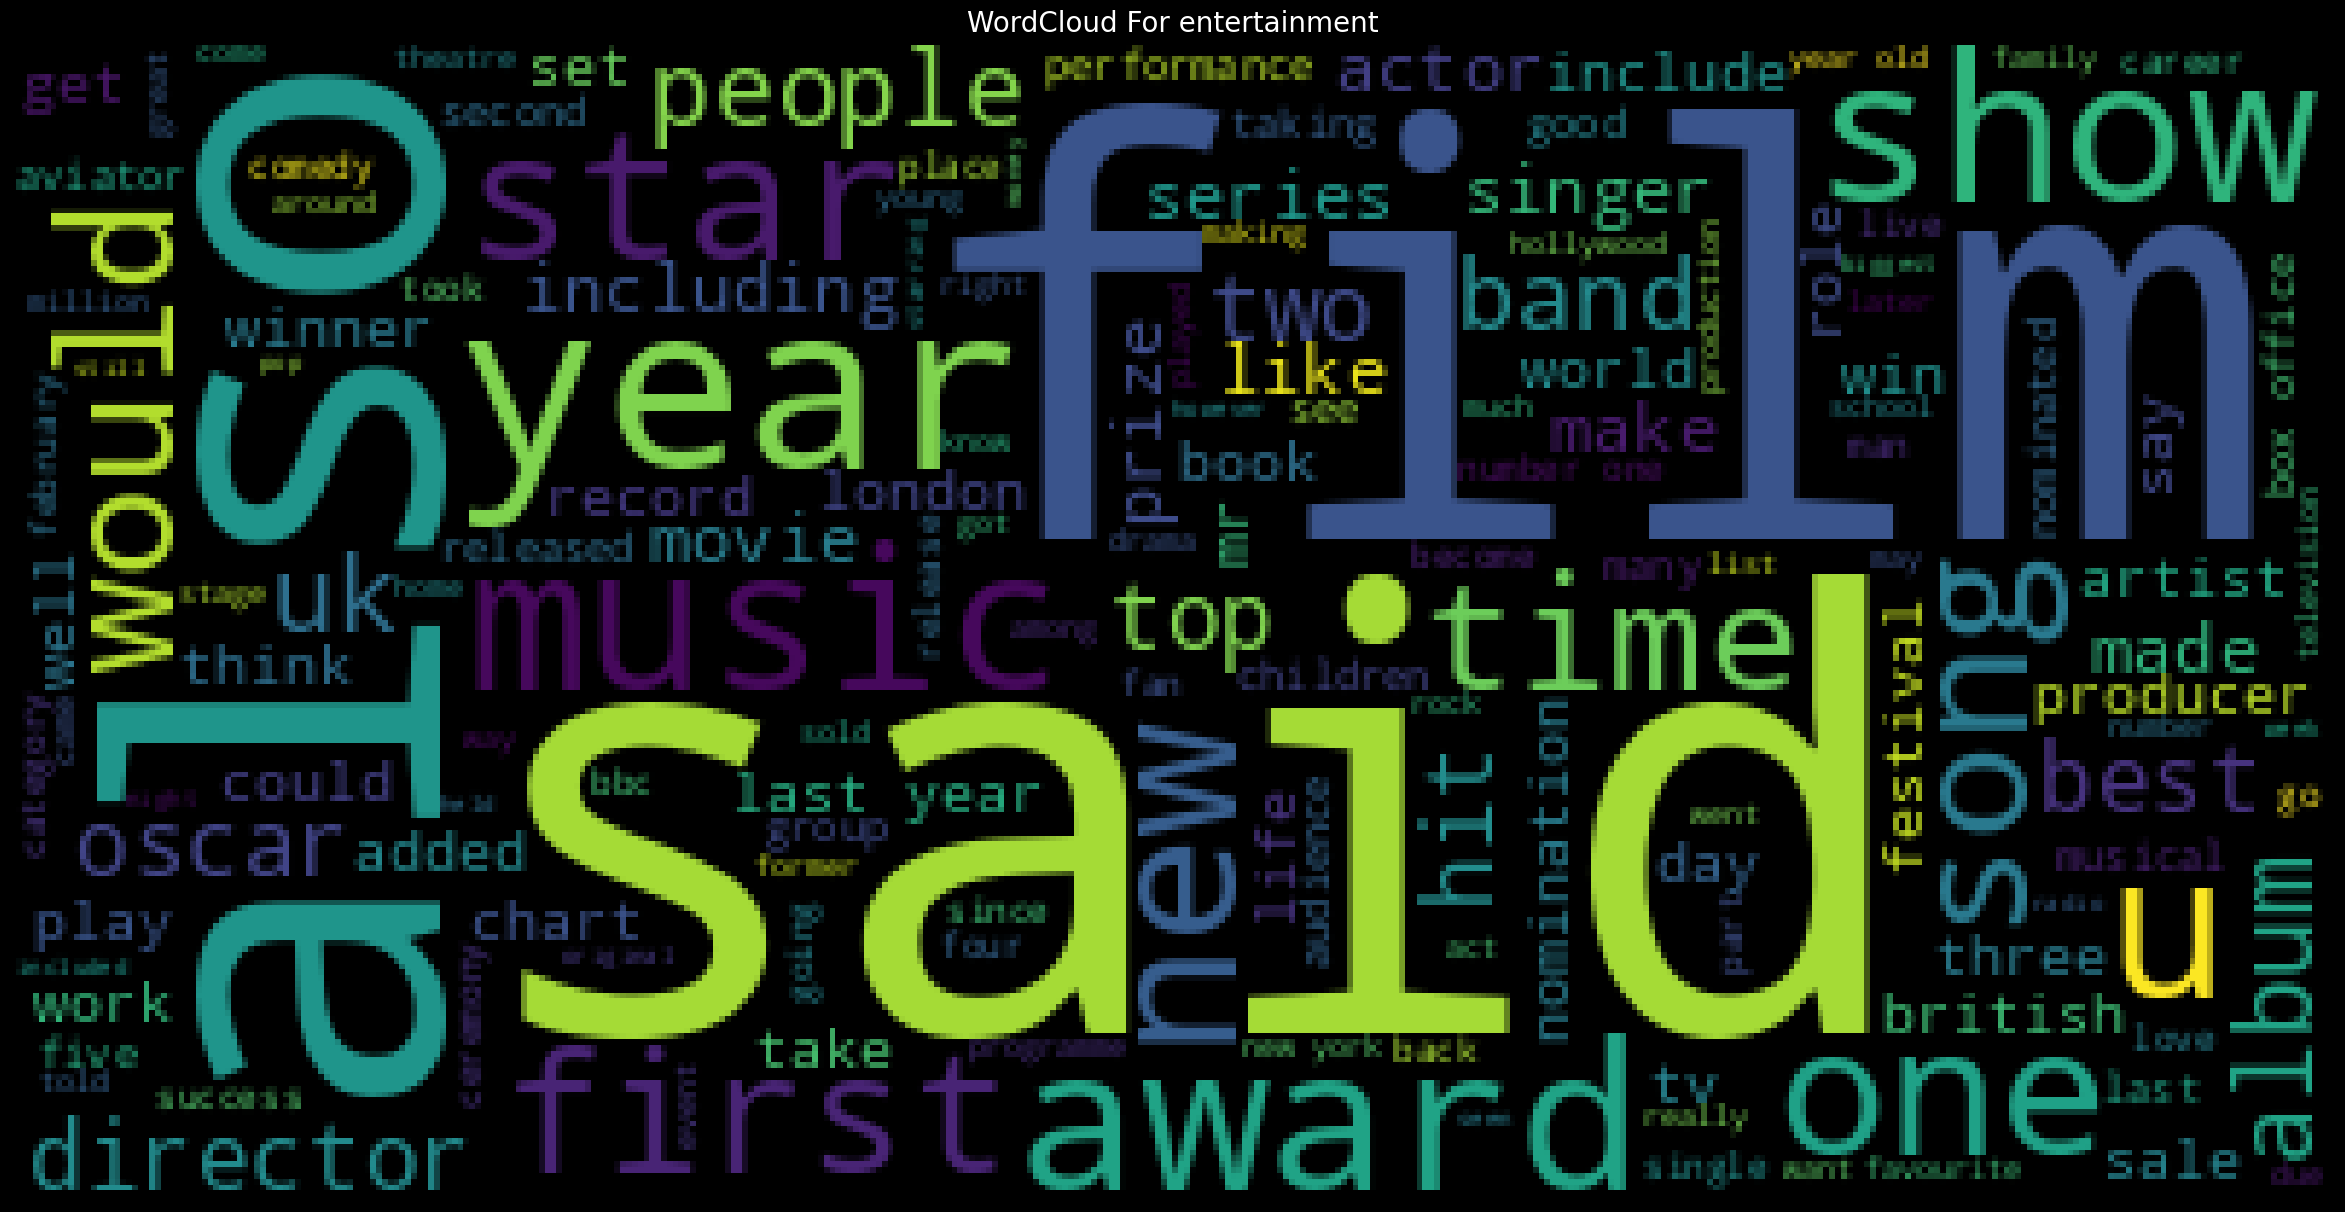

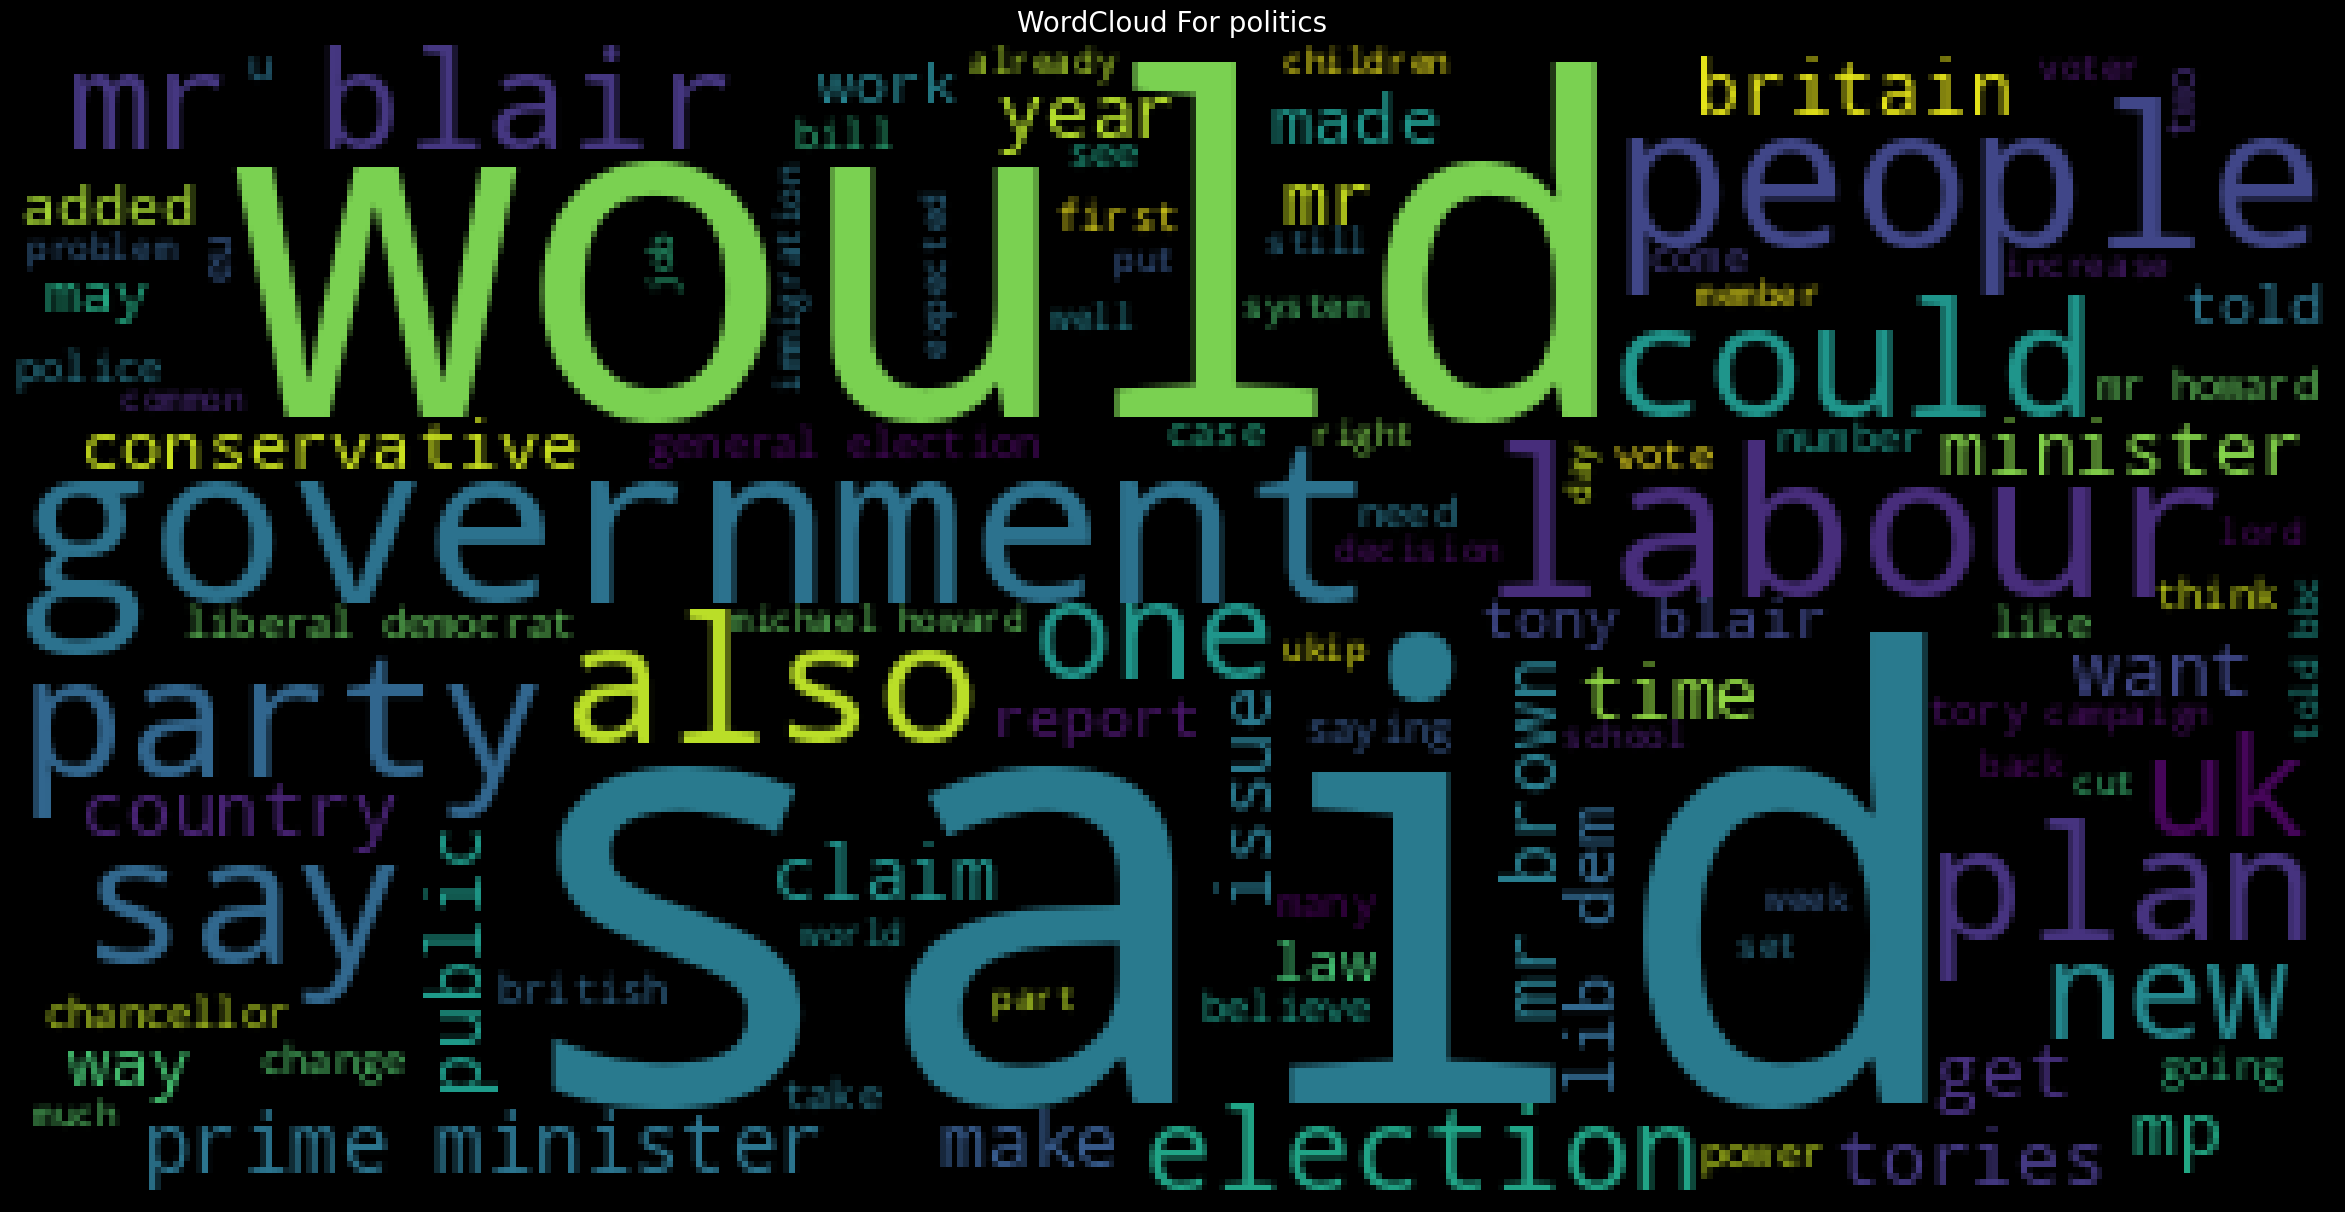

In [11]:
import nltk
nltk.download('stopwords')

for value in data.category.unique():
    plt.figure(figsize=(30,30))
    plt.imshow(WordCloud(background_color = 'black',stopwords=set(stopwords.words('english'))).generate(" ".join(data.text[data.category==value])))
    plt.axis("off")
    plt.title(f"WordCloud For {value}",fontsize=20)
    plt.show()

In [12]:
english_stopwords = set(stopwords.words('english'))

def clean_bbc_news_text(text):
  text = re.sub(r'[^a-zA-Z\s]','',text)
  text = re.sub(r'\d+','',text)
  text = text.lower()
  words = text.split()
  words = [word for word in words if word not in english_stopwords]
  cleaned_text = ' '.join(words)
  return cleaned_text

In [13]:
data.text = data.text.apply(clean_bbc_news_text)
data.head()

,category,text
0,tech,tv future hands viewers home theatre systems p...
1,business,worldcom boss left books alone former worldcom...
2,sport,tigers wary farrell gamble leicester say rushe...
3,sport,yeading face newcastle fa cup premiership side...
4,entertainment,ocean twelve raids box office ocean twelve cri...


In [14]:
encoder = LabelEncoder()
data.category = encoder.fit_transform(data.category)
data.head()

,category,text
0,4,tv future hands viewers home theatre systems p...
1,0,worldcom boss left books alone former worldcom...
2,3,tigers wary farrell gamble leicester say rushe...
3,3,yeading face newcastle fa cup premiership side...
4,1,ocean twelve raids box office ocean twelve cri...


In [15]:
def Balance_data(data,text,target):
  pass

In [16]:
X_train,X_test,y_train,y_test = train_test_split(data.text,data.category,test_size=0.2,random_state=44,shuffle=True)
print('X_train shape is ',X_train.shape)
print('X_test shape is ',X_test.shape)
print('y_train shape is ',y_train.shape)
print('y_test shape is ',y_test.shape)

X_train shape is  (1780,)
X_test shape is  (445,)
y_train shape is  (1780,)
y_test shape is  (445,)


In [17]:
model_name = 'bert-base-uncased'

distilbert_model = TFBertModel.from_pretrained(model_name)
tokenizer = BertTokenizer.from_pretrained(model_name)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertModel: ['cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.dense.weight', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.bias', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing TFBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertModel for predictions w

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [18]:
def tokenize_data(text,max_length=200):
  return tokenizer(
      text.tolist(),
      max_length = max_length,
      truncation = True,
      padding = 'max_length',
      return_tensors = 'tf'
      )

In [19]:
X_train_data = tokenize_data(X_train)
X_train_data

{'input_ids': <tf.Tensor: shape=(1780, 200), dtype=int32, numpy=
array([[  101,  7513, 26740, ...,  6681, 10372,   102],
       [  101, 18856, 28418, ...,     0,     0,     0],
       [  101,  9805, 15710, ...,  5275, 16625,   102],
       ...,
       [  101, 23413,  2229, ...,     0,     0,     0],
       [  101,  2501,  2095, ...,     0,     0,     0],
       [  101,  5470,  8034, ...,     0,     0,     0]], dtype=int32)>, 'token_type_ids': <tf.Tensor: shape=(1780, 200), dtype=int32, numpy=
array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=int32)>, 'attention_mask': <tf.Tensor: shape=(1780, 200), dtype=int32, numpy=
array([[1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 1, 1, 1],
       ...,
       [1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0]], dtype=in

In [20]:
X_test_data = tokenize_data(X_test)
X_test_data

{'input_ids': <tf.Tensor: shape=(445, 200), dtype=int32, numpy=
array([[  101, 15117,  2379, ...,     0,     0,     0],
       [  101,  3036,  4981, ...,     0,     0,     0],
       [  101,  4684,  2015, ..., 14841,  6767,   102],
       ...,
       [  101,  7391,  2131, ..., 28831, 11183,   102],
       [  101, 15009,  4491, ...,  2349,  3677,   102],
       [  101,  4401,  2067, ...,  8040,  5668,   102]], dtype=int32)>, 'token_type_ids': <tf.Tensor: shape=(445, 200), dtype=int32, numpy=
array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=int32)>, 'attention_mask': <tf.Tensor: shape=(445, 200), dtype=int32, numpy=
array([[1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 1, 1, 1],
       ...,
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1]], dtype=int32

In [23]:
y_train1 = to_categorical(y_train,num_classes=5)
y_test1 = to_categorical(y_test,num_classes=5)

In [26]:
input_ids = Input(shape=(200,), dtype='int32', name='input_ids')
attention_mask = Input(shape=(200,), dtype='int32', name='attention_mask')
def distilbert_fn(inputs):
    return distilbert_model(input_ids=inputs[0], attention_mask=inputs[1]).last_hidden_state
distilbert_layer = Lambda(
    distilbert_fn,
    output_shape=(200, 768)
)([input_ids, attention_mask])
cls_output = Lambda(lambda x: x[:, 0, :])(distilbert_layer)
num_classes = len(data.category.unique())
output = Dense(num_classes, activation='softmax')(cls_output)
model = Model(inputs=[input_ids, attention_mask], outputs=output)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_ids (InputLayer)    │ (None, 200)            │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ attention_mask            │ (None, 200)            │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lambda_2 (Lambda)         │ (None, 200, 768)       │              0 │ input_ids[0][0],       │
│                           │                        │                │ attention_mask[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lambda_3 (Lambda)         │ (None, 768)            │              0 │ lambda_2[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense (Dense)             │ (None, 5)              │          3,845 │ lambda_3[0][0]         │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 3,845 (15.02 KB)

 Trainable params: 3,845 (15.02 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

X_train_input_ids = np.array(X_train_data['input_ids'])

X_train_attention_mask = np.array(X_train_data['attention_mask'])

y_train = np.array(y_train)

history = model.fit(
    [X_train_input_ids,X_train_attention_mask],
    y_train1,
    epochs=20,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 52s 680ms/step - accuracy: 0.4702 - loss: 1.3686 - val_accuracy: 0.8820 - val_loss: 0.7700
Epoch 2/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 20s 385ms/step - accuracy: 0.8993 - loss: 0.6590 - val_accuracy: 0.9270 - val_loss: 0.4767
Epoch 3/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 21s 409ms/step - accuracy: 0.9367 - loss: 0.4439 - val_accuracy: 0.9213 - val_loss: 0.3591
Epoch 4/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 40s 395ms/step - accuracy: 0.9479 - loss: 0.3142 - val_accuracy: 0.9326 - val_loss: 0.2968
Epoch 5/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 21s 399ms/step - accuracy: 0.9496 - loss: 0.2676 - val_accuracy: 0.9326 - val_loss: 0.2614
Epoch 6/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 20s 394ms/step - accuracy: 0.9594 - loss: 0.2215 - val_accuracy: 0.9326 - val_loss: 0.2372
Epoch 7/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 20s 384ms/step - accuracy: 0.9516 - loss: 0.2090 - val_accuracy: 0.9438 - val_loss: 0.2160
Epoch 8/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 20s 384ms/step - accuracy: 0.9606 - loss: 0.1905 - val_accu

In [28]:
hist = pd.DataFrame(history.history)
hist

,accuracy,loss,val_accuracy,val_loss
0,0.652310,1.152525,0.882023,0.770045
1,0.906991,0.595309,0.926966,0.476733
2,0.938826,0.405491,0.921348,0.359143
3,0.942572,0.314743,0.932584,0.296778
4,0.947566,0.262139,0.932584,0.261415
5,0.951935,0.227564,0.932584,0.237216
6,0.950062,0.205316,0.943820,0.216042
7,0.960050,0.186192,0.938202,0.204346
8,0.963795,0.169077,0.938202,0.191664
9,0.962547,0.157507,0.949438,0.181917


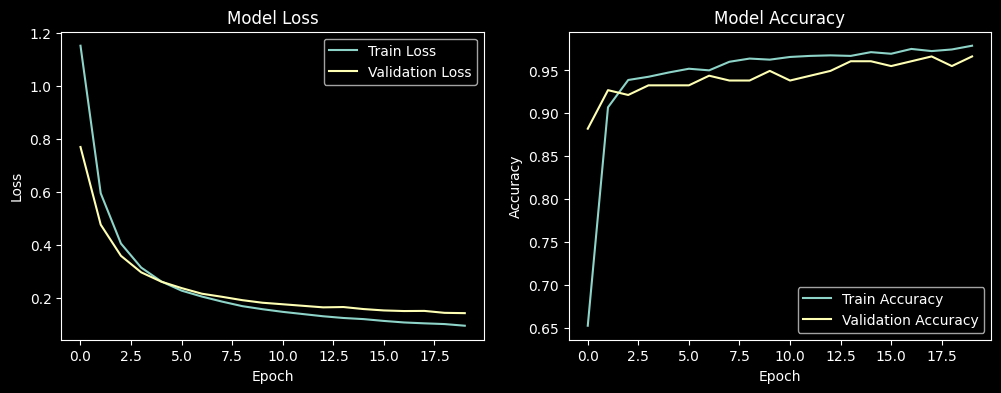

In [29]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [30]:
loss,accuracy = model.evaluate([X_test_data['input_ids'],X_test_data['attention_mask']],y_test1)
print(f'Model Loass : {loss}')
print(f'Model Accuracy : {accuracy * 100}')

14/14 ━━━━━━━━━━━━━━━━━━━━ 8s 556ms/step - accuracy: 0.9714 - loss: 0.0976
Model Loass : 0.0912557989358902
Model Accuracy : 97.75280952453613


In [31]:
predictions = model.predict([X_test_data['input_ids'],X_test_data['attention_mask']])
y_pred = np.argmax(predictions,axis=1)
y_pred[:10]

14/14 ━━━━━━━━━━━━━━━━━━━━ 14s 784ms/step


array([0, 2, 4, 1, 3, 4, 2, 2, 3, 0])

In [32]:
class_names = encoder.classes_
class_names

array(['business', 'entertainment', 'politics', 'sport', 'tech'],
      dtype=object)

Confusion Matrix is : 
 [[ 83   1   0   0   3]
 [  1  83   0   0   1]
 [  0   0  90   0   1]
 [  0   0   0 107   0]
 [  1   0   2   0  72]]


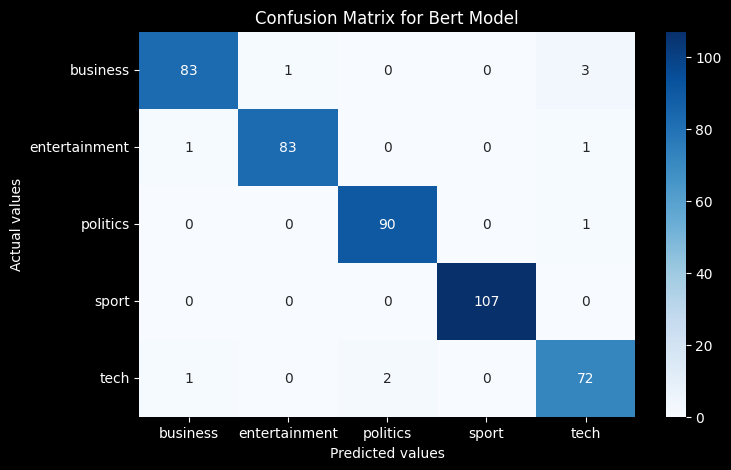

In [33]:
CM = confusion_matrix(y_test, y_pred)
print('Confusion Matrix is : \n', CM)
plt.figure(figsize=(8,5))
sns.heatmap(data=CM, annot=True,fmt='g', cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted values')
plt.ylabel('Actual values')
plt.title('Confusion Matrix for Bert Model')
plt.show()

In [34]:
ClassificationReport = classification_report(y_test, y_pred,target_names=class_names)
print('Classification Report is : ', ClassificationReport )

Classification Report is :                 precision    recall  f1-score   support

     business       0.98      0.95      0.97        87
entertainment       0.99      0.98      0.98        85
     politics       0.98      0.99      0.98        91
        sport       1.00      1.00      1.00       107
         tech       0.94      0.96      0.95        75

     accuracy                           0.98       445
    macro avg       0.98      0.98      0.98       445
 weighted avg       0.98      0.98      0.98       445



In [35]:
def Predictive(text):
  text = clean_bbc_news_text(text)
  token = tokenizer(
      text,
      max_length=200,
      truncation=True,
      padding='max_length',
      return_tensors='tf'
  )
  output = np.argmax(model.predict([token['input_ids'],token['attention_mask']]),axis=1)
  return encoder.inverse_transform([output])[0]

In [36]:
test_sentence = "The stock market saw a significant increase today, with tech companies leading the way."
result = Predictive(test_sentence)
print(f'The predicted category is : {result}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
The predicted category is : business


In [37]:
test_sentence = "The national football team secured a thrilling victory in the championship final last night."
result = Predictive(test_sentence)
print(f"The predicted category is: {result}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
The predicted category is: sport


In [38]:
test_sentence = "The movie's release is set to break box office records this weekend, with fans eagerly awaiting the premiere."
result = Predictive(test_sentence)
print(f"The predicted category is: {result}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
The predicted category is: entertainment
